# 07_Simple Linear Regression

# Simple Linear Regression

두 Numerical Variables 사이에 관계가 있다면 한 Variable을 이용하여 다른 Variable을 예측할 수 있을까?

예를 들어 $x$가 증가할수록 $y$도 일정한 방향으로 증가하는 Data가 있다고 하자.

이러한 관계를 하나의 직선으로 표현할 수 있다면 새로운 $x$가 주어졌을 때 $y$를 예측할 수 있다.

이번 강의에서는 하나의 Input Variable을 이용하여 Numerical Output을 예측하는 Simple Linear Regression을 학습한다.

> Relationship → Model → Prediction

## Linear Data

먼저 두 Variables 사이에 비교적 명확한 Linear Relationship이 존재하는 Data를 살펴보자.

`linear_data.csv`에는 두 Numerical Variables `x`와 `y`가 있다고 하자.

먼저 Data를 직접 확인하고 두 Variables 사이의 관계를 Visualization한다.

Machine Learning Method를 적용하기 전에 Data의 특징을 먼저 관찰하는 것이 중요하다.

In [1]:
from google.colab import drive

# Google Drive를 Colab에 Mount
drive.mount('/content/drive')

# 강의용 Data가 저장된 Folder

data_path = "/content/drive/My Drive/Colab Notebooks/0_ML/Input/"

Mounted at /content/drive


In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Data 읽기
df = pd.read_csv(data_path+"linear_data.csv")

# Data 확인
display(df.head())

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

,input,output
0,0.378729,-2.101773
1,0.988323,-3.376486
2,0.168299,-0.736341
3,0.746678,-2.030376
4,0.380839,-1.833090


Shape: (100, 2)
Columns: ['input', ' output']


Index(['input', ' output'], dtype='object')


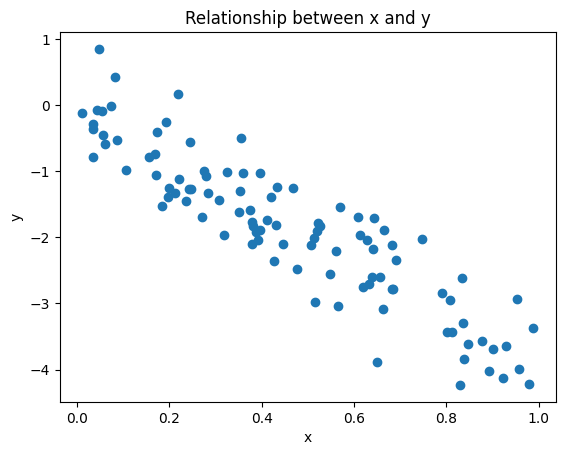

Correlation: -0.9078322620621022


In [21]:
# x와 y의 관계를 Scatter Plot으로 확인
print(df.columns)
plt.scatter(df["input"], df[" output"])

plt.xlabel("x")
plt.ylabel("y")
plt.title("Relationship between x and y")

plt.show()

# Correlation 확인
print("Correlation:", df["input"].corr(df[" output"]))

In [22]:
# Input X와 Output y 선택
X = df[["input"]]
y = df[" output"]

# Data의 Shape 확인
print("X Shape:", X.shape)
print("y Shape:", y.shape)

display(X.head())
display(y.head())

X Shape: (100, 1)
y Shape: (100,)


,input
0,0.378729
1,0.988323
2,0.168299
3,0.746678
4,0.380839


,output
0,-2.101773
1,-3.376486
2,-0.736341
3,-2.030376
4,-1.833090


## From Relationship to Prediction

Scatter Plot을 보면 `MedInc`가 증가할수록 `MedHouseVal`도 증가하는 경향이 있다.

이 관계를 하나의 직선으로 표현해 볼 수 있다.

Input을 $x$, 예측값을 $\hat{y}$라고 하면 가장 간단한 Linear Model은 다음과 같다.

$$
\hat{y}=wx+b
$$

여기서

- $x$: Input
- $\hat{y}$: Prediction
- $w$: Weight
- $b$: Bias

이다.

Simple Linear Regression은 하나의 Input Variable과 Output Variable 사이의 관계를 직선으로 표현하는 방법이다.

## What Does the Model Learn?

Model을 만들기 전에 $w$와 $b$의 값을 알 수 없다.

Machine Learning에서는 Data를 이용하여 이 값을 결정한다.

$$
\hat{y}=wx+b
$$

에서 $w$와 $b$는 Model의 Parameter이다.

Training은 Data를 이용하여 적절한 Parameter를 찾는 과정이다.

> Data → Training → Parameters → Model

Simple Linear Regression에서는 결국 Data를 가장 잘 설명하는 하나의 직선을 찾는다.

## Input and Output

Machine Learning Problem에서는 Input과 Output을 명확하게 정의해야 한다.

현재 Problem에서는

$$
X=x
$$

이고

$$
y=y
$$

이다.

Output이 연속적인 Numerical Value이므로 Regression Problem이다.

이제 Data를 $X$와 $y$로 분리하여 Model을 Training한다.

## Creating a Linear Regression Model

Python의 `scikit-learn`을 이용하면 Linear Regression Model을 만들 수 있다.

Machine Learning에서는 일반적으로 다음 과정을 사용한다.

> Create Model → Train Model → Predict

Model을 만드는 것과 Model을 Training하는 것은 서로 다른 과정이다.

먼저 어떤 Machine Learning Method를 사용할 것인지 결정하여 Model을 생성한다.

그 다음 Data를 이용하여 Model을 Training한다.

In [23]:
from sklearn.linear_model import LinearRegression

# Linear Regression Model 생성
model = LinearRegression()

# X와 y를 이용하여 Model Training
model.fit(X, y)

print("Training Complete")

Training Complete


## Learned Parameters

Training이 끝나면 Model은 Data를 설명하는 $w$와 $b$를 가지고 있다.

$$
\hat{y}=wx+b
$$

$w$는 Input $x$가 1만큼 증가할 때 Prediction이 얼마나 변하는지를 나타낸다.

$b$는 직선의 시작 위치를 결정한다.

실제로 Model이 어떤 Parameter를 학습했는지 확인해 보자.

In [24]:
# Training으로 결정된 Parameter 확인
w = model.coef_[0]
b = model.intercept_

print("Weight:", w)
print("Bias:", b)

# 학습된 Linear Model의 식 확인
print(f"MedHouseVal = {w:.4f} × MedInc + {b:.4f}")

Weight: -3.8225306779272312
Bias: -0.10165774122152804
MedHouseVal = -3.8225 × MedInc + -0.1017


## Regression Line

학습된 Model이 Data를 어떻게 표현하고 있는지 Scatter Plot 위에 Regression Line을 그려 보자.

각 Point는 실제 Data를 나타낸다.

Regression Line은 Model이 학습한 관계를 나타낸다.

모든 Data Point를 직선이 정확하게 통과할 필요는 없다.

Linear Regression의 목적은 전체 Data의 관계를 하나의 직선으로 표현하는 것이다.

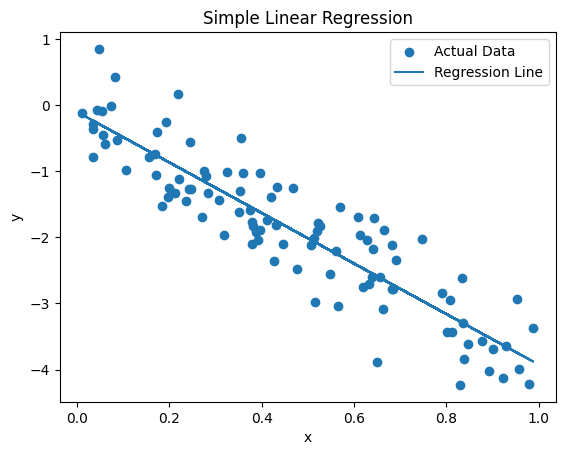

In [27]:
# Training Data에 대한 Prediction
y_pred = model.predict(X)

# 실제 Data
plt.scatter(
    X["input"],
    y,
    label="Actual Data"
)

# Regression Line
plt.plot(
    X["input"],
    y_pred,
    label="Regression Line"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Simple Linear Regression")
plt.legend()

plt.show()

## Prediction

Training된 Model의 중요한 목적은 새로운 Input에 대한 Output을 예측하는 것이다.

예를 들어 Median Income이 5인 지역의 Median House Value를 알고 싶다고 하자.

Training된 Model에 새로운 $x$를 입력하면 다음과 같이 Prediction을 얻을 수 있다.

$$
x \rightarrow \hat{y}
$$

이것이 Machine Learning Model을 이용한 Prediction이다.

In [29]:
# 새로운 Input
new_data = pd.DataFrame({
    "input": [5.0, 10.0, 15.0]
})

# 새로운 Input에 대한 Prediction
prediction = model.predict(new_data)

result = new_data.copy()
result["Predicted_y"] = prediction

display(result)

,input,Predicted_y
0,5.0,-19.214311
1,10.0,-38.326965
2,15.0,-57.439618


## Actual Value and Predicted Value

Model의 Prediction은 실제 값과 정확히 같지 않을 수 있다.

실제 값을 $y$, Model의 Prediction을 $\hat{y}$라고 하면 두 값의 차이를 Error 또는 Residual이라고 할 수 있다.

$$
e=y-\hat{y}
$$

Error가 작을수록 해당 Sample에 대해 Model의 Prediction이 실제 값에 가깝다.

Machine Learning에서는 Model을 만드는 것뿐 아니라 Prediction이 실제 Data를 얼마나 잘 설명하는지 확인하는 것이 중요하다.

In [30]:
# 처음 10개 Sample의 실제 값과 Prediction 비교
result = pd.DataFrame({
    "Actual": y.iloc[:10],
    "Predicted": y_pred[:10]
})

# Error 계산
result["Error"] = result["Actual"] - result["Predicted"]

display(result)

,Actual,Predicted,Error
0,-2.101773,-1.549362,-0.552410
1,-3.376486,-3.879551,0.503065
2,-0.736341,-0.744985,0.008644
3,-2.030376,-2.955858,0.925481
4,-1.833090,-1.557426,-0.275664
5,-2.784982,-2.714380,-0.070602
6,-1.385232,-0.853804,-0.531428
7,-2.593447,-2.612992,0.019545
8,-0.119637,-0.145326,0.025689
9,0.851893,-0.281040,1.132932


## Mean Squared Error

Model의 Error를 전체 Data에 대해 평가하려면 하나의 숫자로 요약할 필요가 있다.

Regression에서 많이 사용하는 방법 중 하나가 Mean Squared Error (MSE)이다.

$$
MSE=\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$$

각 Sample의 Error를 제곱한 후 평균을 계산한다.

MSE가 작을수록 Prediction과 실제 값의 차이가 작다는 의미이다.

그러나 MSE의 크기는 Output Variable의 Scale에도 영향을 받기 때문에 숫자만 보고 무조건 좋은 Model이라고 판단해서는 안 된다.

In [31]:
from sklearn.metrics import mean_squared_error

# 전체 Data의 MSE 계산
mse = mean_squared_error(y, y_pred)

print("MSE:", mse)

MSE: 0.22938821489018715


## R-squared

Regression Model을 평가하는 또 다른 방법으로 $R^2$를 사용할 수 있다.

$R^2$는 Model이 Output의 변화를 얼마나 설명하고 있는지를 나타내는 지표이다.

일반적으로 $R^2$가 1에 가까울수록 Model이 Data를 잘 설명한다고 볼 수 있다.

그러나 높은 $R^2$가 항상 좋은 Machine Learning Model을 의미하는 것은 아니다.

현재는 Model이 Training Data의 관계를 얼마나 설명하는지 확인하는 지표로 사용한다.

Regression Model의 Prediction을 평가하는 방법으로 Coefficient of Determination ($R^2$)을 사용할 수 있다.

$$
R^2
=
1-
\frac{\sum (y_i-\hat{y}_i)^2}
{\sum (y_i-\bar{y})^2}
$$

$R^2$가 1에 가까울수록 Model이 Output의 변화를 잘 설명한다.

$R^2=1$이면 Actual Value와 Prediction이 완전히 일치한다.

$R^2=0$이면 Output의 Mean을 이용하여 예측하는 것과 비슷한 수준이다.

In [32]:
from sklearn.metrics import r2_score

# R-squared 계산
r2 = r2_score(y, y_pred)

print("R-squared:", r2)

R-squared: 0.8241594160407942


## What about Real Data?

지금까지 사용한 Data에서는 $x$와 $y$ 사이에 비교적 명확한 Linear Relationship이 존재하였다.

그러나 실제 Data에서도 이렇게 명확한 관계가 나타날까?

California Housing Data에서 다음 Problem을 생각해 보자.

> Median Income을 이용하여 Median House Value를 예측할 수 있을까?

먼저 Machine Learning Model을 만들지 말고 Data를 관찰해 보자.

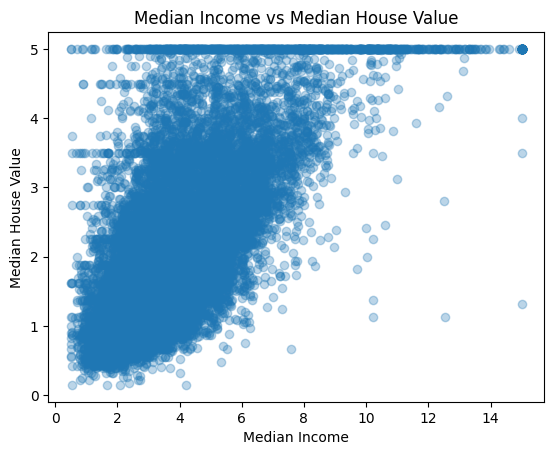

Correlation: 0.6880752079585475


In [34]:
# California Housing Data 읽기
housing = pd.read_csv(data_path+"california_housing.csv")

# MedInc와 MedHouseVal의 관계 확인
plt.scatter(
    housing["MedInc"],
    housing["MedHouseVal"],
    alpha=0.3
)

plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Median Income vs Median House Value")

plt.show()

# Correlation 확인
print(
    "Correlation:",
    housing["MedInc"].corr(housing["MedHouseVal"])
)

## Can We Use a Linear Model?

Scatter Plot에서는 전체적으로 `MedInc`가 증가하면서 `MedHouseVal`도 증가하는 경향을 볼 수 있다.

그러나 처음 사용한 Data와 비교하면 Point들이 하나의 직선 주변에 모여 있지 않다.

또한 `MedHouseVal`이 특정 값에 많이 모여 있는 특이한 Pattern도 보인다.

따라서 다음 질문을 생각해야 한다.

> Linear Regression을 적용할 수 있는가?

> 적용할 수 있다면 얼마나 잘 예측할 수 있는가?

실제 Data에서는 Machine Learning Method를 적용하는 것뿐 아니라 그 Method가 Data에 적절한지를 판단하는 것도 중요하다.

In [35]:
# Input과 Output
X_housing = housing[["MedInc"]]
y_housing = housing["MedHouseVal"]

# Linear Regression Model
housing_model = LinearRegression()

# Training
housing_model.fit(X_housing, y_housing)

# Prediction
housing_pred = housing_model.predict(X_housing)

# Evaluation
print("Weight:", housing_model.coef_[0])
print("Bias:", housing_model.intercept_)

print(
    "MSE:",
    mean_squared_error(y_housing, housing_pred)
)

print(
    "R-squared:",
    r2_score(y_housing, housing_pred)
)

Weight: 0.41793849201896277
Bias: 0.45085576703267893
MSE: 0.7011311502929527
R-squared: 0.47344749180719903


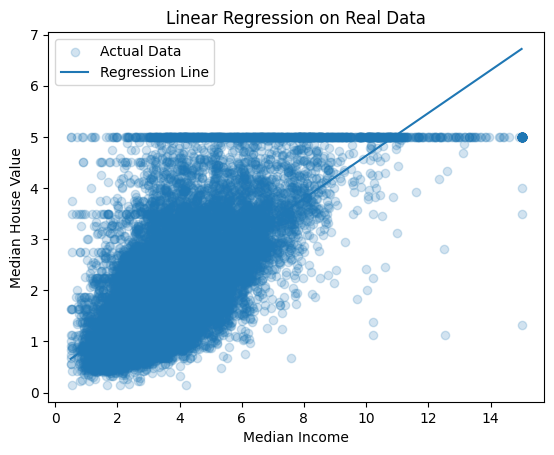

In [36]:
# 실제 Data와 Regression Line 비교
plt.scatter(
    housing["MedInc"],
    housing["MedHouseVal"],
    alpha=0.2,
    label="Actual Data"
)

# Regression Line이 올바른 순서로 표시되도록 x 기준 정렬
order = X_housing["MedInc"].argsort()

plt.plot(
    X_housing["MedInc"].iloc[order],
    housing_pred[order],
    label="Regression Line"
)

plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Linear Regression on Real Data")
plt.legend()

plt.show()

## Summary

Simple Linear Regression은 하나의 Input Variable을 이용하여 Numerical Output을 예측한다.

Model은 다음과 같이 표현된다.

$$
\hat{y}=wx+b
$$

Training은 Data를 이용하여 Weight와 Bias를 결정하는 과정이다.

Training된 Model을 이용하여 새로운 Input에 대한 Output을 Prediction할 수 있다.

MSE와 $R^2$ 등을 이용하여 Prediction 결과를 평가할 수 있다.

그러나 실제 Data가 항상 명확한 Linear Relationship을 가지는 것은 아니다.

Machine Learning에서는 Model을 만드는 것뿐 아니라 Model이 Data를 얼마나 잘 설명하는지를 판단하는 것이 중요하다.

> Problem → Data → Model → Training → Prediction → Evaluation → Interpretation

### HW_07

`Input/california_housing.csv`에서 `AveRooms`를 이용하여 `MedHouseVal`을 예측하는 Simple Linear Regression Model을 만들고 다음 질문에 답하시오.

- `AveRooms`와 `MedHouseVal`의 Correlation 값을 소수점 셋째 자리까지 적으시오.
- 학습된 Model의 Weight를 소수점 셋째 자리까지 적으시오.
- 학습된 Model의 Bias를 소수점 셋째 자리까지 적으시오.
- Model의 MSE를 소수점 셋째 자리까지 적으시오.
- Model의 $R^2$를 소수점 셋째 자리까지 적으시오.
- `AveRooms = 6.0`일 때 Model이 예측하는 `MedHouseVal`을 소수점 셋째 자리까지 적으시오.

답만 제출하시오.